<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 4.2
### **Date:** 04/09/2026
---
Reference: 

UCI Machine Learning. (2016). *Auto-mpg dataset* [Dataset]. Kaggle. https://www.kaggle.com/datasets/uciml/autompg-dataset

UCI Machine Learning Repository. (1993). *Auto MPG dataset*. https://archive.ics.uci.edu/dataset/9/auto+mpg

</div>

### **Initial Setup:**

In [42]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Global viz formatting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
GREEN = '#228B22'

# Load dataset
df = pd.read_csv('auto-mpg.csv')

print('✅ Dataset loaded successfully!')
print(f'📐 Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'📋 Columns: {list(df.columns)}')

✅ Dataset loaded successfully!
📐 Shape: 398 rows x 9 columns
📋 Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']


---
## Step 1: Load and Inspect the Data

Before any modeling can begin, we verify the dataset imported correctly by reviewing its shape, data types, and checking for any immediately visible issues such as missing values or unexpected formatting.

In [43]:
# Initial data inspection
print('🔍 First 5 rows:')
display(df.head())

print('\n📊 Data types and non-null counts:')
display(df.info())

print('\n🔢 Summary statistics:')
display(df.describe())

print('\n❓ Null values per column:')
display(df.isnull().sum())

🔍 First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



📊 Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB


None


🔢 Summary statistics:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000



❓ Null values per column:


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

<div style="page-break-before: always;"></div>

---
## Step 2: Data Preparation

With the initial inspection complete, we now prepare the data for modeling. This involves three steps: removing the car name column, which carries no predictive value; correcting the horsepower column by identifying and replacing non-numeric placeholders with the column mean; and creating dummy variables for the origin column, which represents categorical geographic regions rather than a true numeric scale. (UCI Machine Learning Repository, 1993)

In [44]:
# Drop car name (no predictive value
df = df.drop(columns=['car name'])
print('🗑️ Car name column removed.')

# Identify non-numeric values in horsepower
non_numeric = df[df['horsepower'] == '?']['horsepower'].value_counts()
print(
    f'\n🔎 Non-numeric values found in horsepower: {non_numeric.sum()} rows marked as "?"')

# Replace "?" with NaN, convert to float, fill with column mean
df['horsepower'] = df['horsepower'].replace('?', np.nan).astype(float)
hp_mean = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(hp_mean)
print(f'🔧 Replaced missing horsepower values with column mean: {hp_mean:.2f}')

# Create dummy variables for origin (drop first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['origin'], drop_first=True, dtype=int)
print(f'\n✅ Dummy variables created for origin.')
print(f'📐 Updated shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'📋 Updated columns: {list(df.columns)}')

🗑️ Car name column removed.

🔎 Non-numeric values found in horsepower: 6 rows marked as "?"
🔧 Replaced missing horsepower values with column mean: 104.47

✅ Dummy variables created for origin.
📐 Updated shape: 398 rows x 9 columns
📋 Updated columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_2', 'origin_3']


<div style="page-break-before: always;"></div>

---
## Step 3: Correlation Matrix and Visualization

To identify which features are most strongly associated with mpg, we generate a correlation coefficient matrix and visualize it as a heatmap. Features with correlation coefficients close to 1 or -1 indicate a strong linear relationship with the target variable.

📊 Correlation coefficients with mpg:
mpg             1.000000
model year      0.579267
origin_3        0.442174
acceleration    0.420289
origin_2        0.259022
horsepower     -0.771437
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741


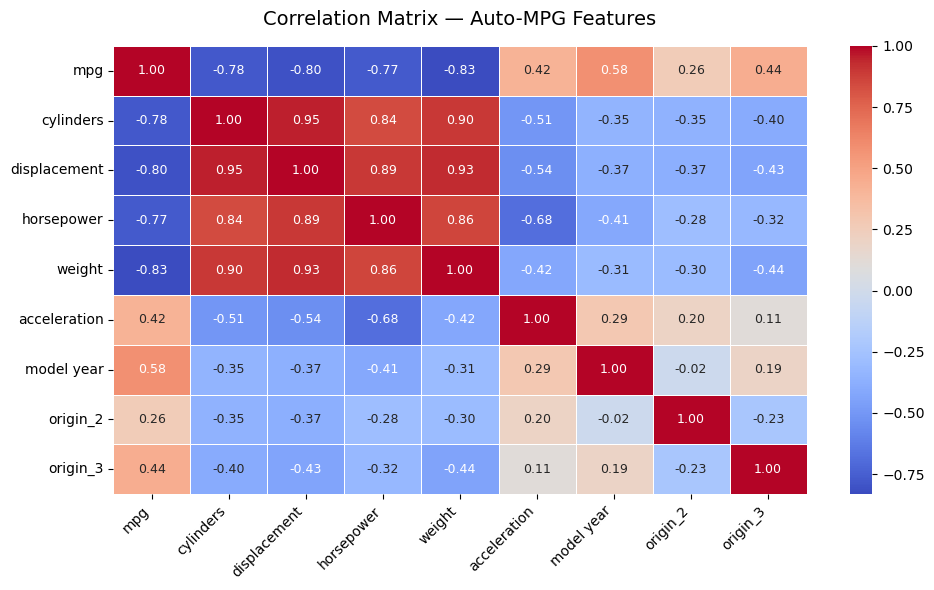


✅ Correlation matrix complete.


In [45]:
# Correlation matrix
corr_matrix = df.corr()

print('📊 Correlation coefficients with mpg:')
print(corr_matrix['mpg'].sort_values(ascending=False).to_string())

# Heatmap
plt.figure()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix — Auto-MPG Features', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n✅ Correlation matrix complete.')

<div style="page-break-before: always;"></div>

<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Summary

The correlation matrix reveals several features with strong linear relationships with mpg. Weight shows the strongest negative correlation, at -0.83, indicating that heavier vehicles are strongly associated with lower fuel efficiency. Displacement and cylinders follow closely at -0.80 and -0.78, respectively, which makes physical sense as larger, more powerful engines tend to consume more fuel. Horsepower also shows a strong negative correlation at -0.77.

On the positive side, model year shows a moderate positive correlation of 0.58, suggesting that newer vehicles in this dataset tend to be more fuel efficient, likely reflecting improvements in automotive engineering over time. The origin dummy variables show weaker positive correlations, with origin_3 at 0.44 and origin_2 at 0.26, suggesting that vehicles from those regions trend toward higher fuel efficiency compared to the origin_1 reference group.

Acceleration shows a modest positive correlation of 0.42, though this may reflect an indirect relationship with engine size rather than a direct effect on fuel efficiency.

</div>

---
## Step 4: MPG versus Weight Scatter Plot

Weight was identified as the most strongly correlated feature with mpg at -0.83. We plot these two variables directly to visualize the nature and strength of that relationship.

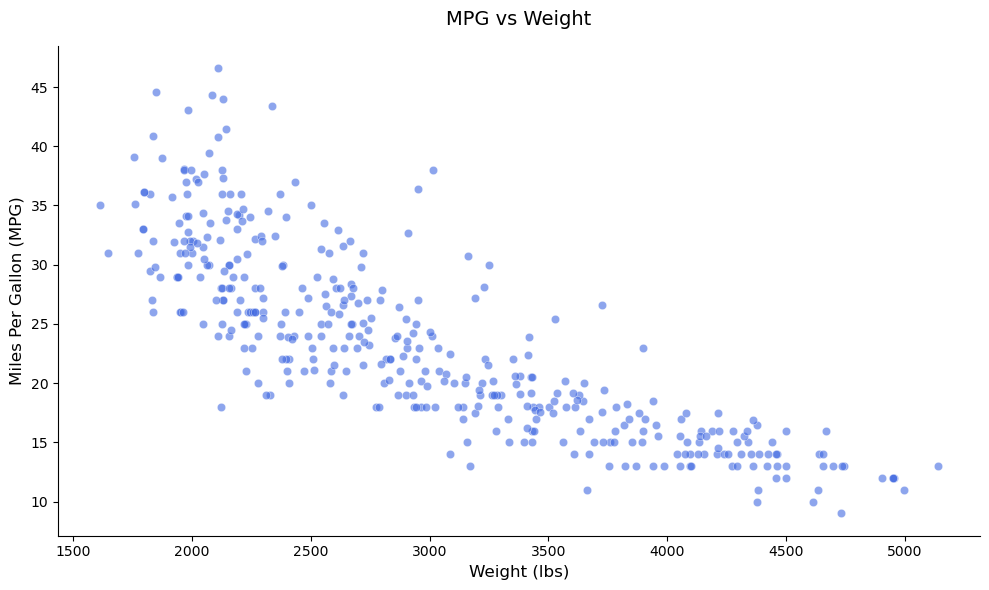

📈 Correlation between weight and mpg: -0.8317


In [46]:
# MPG vs Weight scatter plot
plt.figure()
plt.scatter(
    df['weight'],
    df['mpg'],
    color=ROYAL_BLUE,
    alpha=0.6,
    edgecolors='white',
    linewidths=0.4
)
plt.title('MPG vs Weight', pad=15)
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.tight_layout()
plt.show()

print(
    f'📈 Correlation between weight and mpg: {df["weight"].corr(df["mpg"]):.4f}')

<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">
    
### Summary

The scatter plot reveals a clear negative relationship between vehicle weight and fuel efficiency, consistent with the correlation coefficient of -0.83. As weight increases, mpg decreases in a consistent downward pattern, confirming weight as the strongest single predictor of fuel efficiency in this dataset. The relationship appears slightly curved rather than perfectly linear, suggesting that while a linear model will capture the general trend, some variation may go unexplained. The spread of data points also widens at lower weight values, indicating more variability in fuel efficiency among lighter vehicles than among heavier ones.

</div>

<div style="page-break-before: always;"></div>

---
## Step 5: Train/Test Split

The dataset is randomly split into 80% training data and 20% test data using a fixed random state to ensure reproducibility. The target variable is mpg and the remaining columns serve as features.

In [47]:
# Train/test split
X = df.drop(columns=['mpg'])
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('✅ Train/test split complete.')
print(f'🏋️ Training samples: {X_train.shape[0]:,}')
print(f'🧪 Test samples: {X_test.shape[0]:,}')
print(f'📋 Features: {list(X.columns)}')

✅ Train/test split complete.
🏋️ Training samples: 318
🧪 Test samples: 80
📋 Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_2', 'origin_3']


---
## Step 6: Ordinary Linear Regression — Training and Evaluation

An ordinary least squares linear regression model is trained on the training data and evaluated on both the training and test sets. R², RMSE, and MAE are calculated for each to assess model performance and check for overfitting.

In [48]:
# Ordinary linear regression — training and evaluation
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Metrics
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)

print('📊 Ordinary Linear Regression Results:')
print(f'\n{"Metric":<10} {"Train":>10} {"Test":>10}')
print('-' * 32)
print(f'{"R²":<10} {r2_train_lr:>10.4f} {r2_test_lr:>10.4f}')
print(f'{"RMSE":<10} {rmse_train_lr:>10.4f} {rmse_test_lr:>10.4f}')
print(f'{"MAE":<10} {mae_train_lr:>10.4f} {mae_test_lr:>10.4f}')

📊 Ordinary Linear Regression Results:

Metric          Train       Test
--------------------------------
R²             0.8188     0.8449
RMSE           3.3703     2.8878
MAE            2.6055     2.2876


<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Summary

The ordinary linear regression model performs consistently across both the training and test sets. The R² of 0.82 on training and 0.84 on test indicates that the model explains roughly 82-84% of the variance in fuel efficiency, which is a strong result for a linear model. Notably, the test R² is slightly higher than the training R², which is an uncommon but not alarming outcome in smaller datasets and suggests the model is not overfitting.

The RMSE of 3.37 on training and 2.89 on test indicates that, on average, the model's predictions fall within approximately 3 mpg of the actual value. The MAE of 2.61 on training and 2.29 on test further supports this, suggesting the typical prediction error is just under 2.5 mpg. The slight improvement in error metrics on the test set relative to training is consistent with the R² pattern and reinforces that the model generalizes well to unseen data.

</div>

---
## Step 7: Random Forest Regression — Training and Evaluation

A Random Forest Regressor is trained as a second model for comparison against the ordinary linear regression baseline. Random Forest is an ensemble method that builds multiple decision trees and averages their predictions, making it well suited to capture the nonlinear relationships observed in the data.

In [49]:
# Random Forest Regression — training and evaluation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Metrics
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)

print('🌲 Random Forest Regression Results:')
print(f'\n{"Metric":<10} {"Train":>10} {"Test":>10}')
print('-' * 32)
print(f'{"R²":<10} {r2_train_rf:>10.4f} {r2_test_rf:>10.4f}')
print(f'{"RMSE":<10} {rmse_train_rf:>10.4f} {rmse_test_rf:>10.4f}')
print(f'{"MAE":<10} {mae_train_rf:>10.4f} {mae_test_rf:>10.4f}')

🌲 Random Forest Regression Results:

Metric          Train       Test
--------------------------------
R²             0.9810     0.9106
RMSE           1.0909     2.1926
MAE            0.7478     1.6283


<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Summary

The Random Forest model outperforms ordinary linear regression on the test set, achieving an R² of 0.91 compared to 0.84, and reducing RMSE from 2.89 to 2.19 and MAE from 2.29 to 1.63. This improvement is consistent with the expectation that an ensemble method would better capture the nonlinear relationships observed in the data, particularly the slight curve noted in the mpg versus weight scatter plot.

However, the gap between the training R² of 0.98 and the test R² of 0.91 indicates mild overfitting. The model memorizes some patterns in the training data that do not fully generalize to unseen observations. While the test metrics are still strong, this gap suggests the linear regression model generalizes more consistently, even if its overall accuracy is slightly lower.

In practice, the choice between these two models would depend on the priority. If minimizing prediction error is the goal, Random Forest is the stronger performer. If interpretability and generalization consistency are more important, ordinary linear regression remains a competitive and more transparent option.

</div>

<div style="page-break-before: always;"></div>

# **Final Summary**

In [50]:
# Final summary comparison table
print('📋 Model Comparison Summary:')
print(f'\n{"Metric":<10} {"LR Train":>10} {"LR Test":>10} {"RF Train":>10} {"RF Test":>10}')
print('-' * 52)
print(f'{"R²":<10} {r2_train_lr:>10.4f} {r2_test_lr:>10.4f} {r2_train_rf:>10.4f} {r2_test_rf:>10.4f}')
print(f'{"RMSE":<10} {rmse_train_lr:>10.4f} {rmse_test_lr:>10.4f} {rmse_train_rf:>10.4f} {rmse_test_rf:>10.4f}')
print(f'{"MAE":<10} {mae_train_lr:>10.4f} {mae_test_lr:>10.4f} {mae_train_rf:>10.4f} {mae_test_rf:>10.4f}')

📋 Model Comparison Summary:

Metric       LR Train    LR Test   RF Train    RF Test
----------------------------------------------------
R²             0.8188     0.8449     0.9810     0.9106
RMSE           3.3703     2.8878     1.0909     2.1926
MAE            2.6055     2.2876     0.7478     1.6283


<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### Assignment Summary

This notebook built and evaluated two regression models to predict automobile fuel efficiency using the Auto-MPG dataset. Following data preparation, which included removing the car name column, imputing six missing horsepower values with the column mean, and encoding the origin column as dummy variables, exploratory analysis identified weight, displacement, cylinders, and horsepower as the most strongly correlated features with mpg.

Ordinary linear regression produced an R² of 0.84 on the test set with an RMSE of 2.89 and MAE of 2.29, performing consistently across training and test sets with no signs of overfitting. Random Forest Regression improved on these results with a test R² of 0.91, RMSE of 2.19, and MAE of 1.63, though a gap between training and test R² of 0.98 and 0.91, respectively, indicated mild overfitting. Both models confirm that vehicle weight, engine size, and model year are meaningful predictors of fuel efficiency, with Random Forest offering greater predictive accuracy at the cost of some generalizability and interpretability.

</div>

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

## Reflection

### Overall Reflection
This assignment strengthened my understanding of the full regression modeling workflow, from data cleaning through model evaluation. Working with the Auto MPG dataset helped reinforce how important careful preprocessing is, especially when dealing with mixed data types and legacy formatting issues. The feedback highlighted that while my technical steps were correct, I can improve the clarity and precision of my explanations—particularly around how missing or malformed values behave before conversion. The exercise also emphasized the value of comparing linear and nonlinear models to understand how different algorithms capture relationships in the data.

### Straightforward Aspects
Several components of the assignment felt intuitive. Loading the dataset, removing the `car name` column, and identifying the horsepower formatting issue were all clear steps. Creating dummy variables for the `origin` column and generating the correlation heatmap were also straightforward, and the strong negative correlation between weight and mpg aligned well with expectations. Training the linear regression and random forest models, calculating R², RMSE, and MAE, and interpreting the results were familiar tasks that reinforced core predictive modeling concepts.

### More Challenging Aspects
The most challenging part was ensuring that my explanations were both concise and technically complete. The feedback about noting that `"?"` values are not treated as null until explicitly converted was especially helpful—I handled the issue correctly in code but did not articulate the underlying reason clearly. Another challenge was avoiding repetition in my narrative descriptions; I tended to restate similar points when discussing correlations and model performance. Going forward, I will focus on tightening my explanations and being more deliberate about highlighting only the most relevant insights. This assignment helped me see how small improvements in clarity can make the overall analysis more polished and professional.

</div>